In [1]:
print("My neuroscience python environment is working!")

My neuroscience python environment is working!


# Simulated Behavioral Analysis

## Aim

This notebook simulates trial-level data from an interference task. It compares
reaction time and accuracy between congruent and incongruent conditions.

The data are synthetic and do not represent real participants.

In [2]:
import numpy as np
import pandas as pd

In [6]:
rng = np.random.default_rng(seed=42)

n_trials = 100

conditions = np.repeat(["congruent", "incongruent"], n_trials // 2)
rng.shuffle(conditions)

data = pd.DataFrame({"participant":"sub_001", "trial":np.arange(1, n_trials+1), "condition":conditions})

data["rt_ms"] = np.where(data["condition"] == "congruent", rng.normal(loc=500, scale=60, size=n_trials), rng.normal(loc=600, scale=75, size=n_trials),).round(1)

accuracy_probability = np.where(data["condition"] == "congruent", 0.95, 0.85)

data["correct"]= rng.binomial(1, accuracy_probability)

data.head(10)



,participant,trial,condition,rt_ms,correct
0,sub_001,1,incongruent,628.9,1
1,sub_001,2,congruent,551.5,1
2,sub_001,3,incongruent,596.9,0
3,sub_001,4,congruent,423.5,1
4,sub_001,5,congruent,432.0,1
5,sub_001,6,congruent,444.8,1
6,sub_001,7,incongruent,508.1,1
7,sub_001,8,congruent,508.5,1
8,sub_001,9,incongruent,612.9,1
9,sub_001,10,incongruent,718.4,1


In [8]:
summary=data.groupby("condition").agg(mean_rt_ms=("rt_ms", "mean"), mean_accuracy=("correct", "mean"), n_trials=("trial", "count"),).round(2)

summary

,mean_rt_ms,mean_accuracy,n_trials
condition,,,
congruent,494.75,0.98,50
incongruent,602.72,0.82,50


In [9]:
rt_difference = (summary.loc["incongruent", "mean_rt_ms"]-summary.loc["congruent","mean_rt_ms"])

accuracy_difference = (summary.loc["congruent","mean_accuracy"]-summary.loc["incongruent", "mean_accuracy"])

print(f"Reaction-time interference effect: {rt_difference:.2f} ms")

print(f"Accuracy difference: {accuracy_difference:.0%}")

Reaction-time interference effect: 107.97 ms
Accuracy difference: 16%


In [11]:
from pathlib import Path

data_folder = Path("../data")
figures_folder = Path("../figures")

data_folder.mkdir(exist_ok=True)
figures_folder.mkdir(exist_ok=True)

data.to_csv(data_folder / "simulated_behavior.csv", index=False)

print(f"Dataset saved.")


Dataset saved.


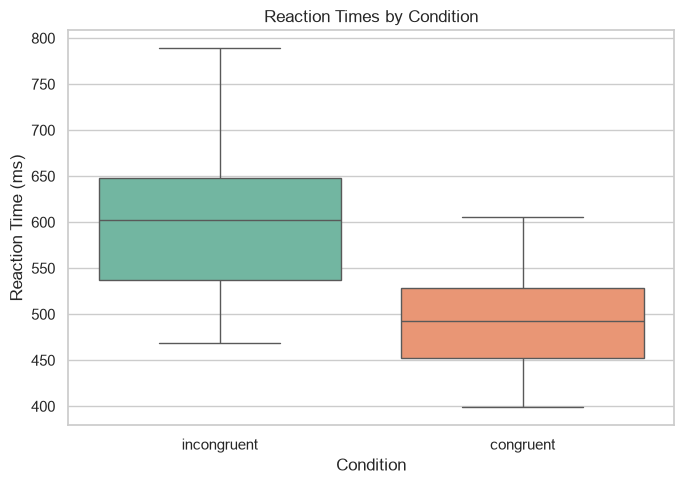

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 5))

sns.boxplot(data=data, x="condition", y="rt_ms", hue="condition", legend=False, palette="Set2")

plt.title("Reaction Times by Condition")
plt.xlabel("Condition")
plt.ylabel("Reaction Time (ms)")
plt.tight_layout()

plt.savefig(figures_folder / "reaction_times_by_condition.png", dpi=300, bbox_inches="tight")

plt.show()

## Results

The simulated participant responded more slowly and less accrurately on incongruent trials than on congruent trials.

- Mean congruent reaction time: 494.75 ms
- Mean incongruent reaction time: 602.72 ms
- Reaction-time interference effect: 107.97
- Congruent accuracy: 97%
- Incongruent accuracy: 82%

These results reflect the parameters used to generate the synthetic data and should not be treated as evidence from a real experiment. 